Script 2

#Testing the embedders for speed and memory

**Objective :** To test three different embedders- EMS2, ProtBERT and ProtT5- on a small stratified dataset to check for their performance and speed. To figure out which embedder we can use based on the computational resources at our disposal.


In [ ]:
# Step 0: Installing necessary libraries

!pip install fair-esm transformers
!pip install umap-learn
!pip install iterative-stratification

In [ ]:
# Step 0: Importing necessary packages

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import time
from tqdm import tqdm
from transformers import BertTokenizer, BertModel, T5Tokenizer, T5EncoderModel
import esm
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve, precision_recall_fscore_support
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

# Check device
device = torch.device("cpu")
print("Using device:", device)

Using device: cpu


In [ ]:
# Step 1: Preprocessing the Data

# Importing the dataset from drive
from google.colab import drive
drive.mount('/content/drive')

# Loading the dataset
df = pd.read_csv('//content/drive/MyDrive/DL/modified_data.csv')

# For initial testing
print(df.index)
print(df.head())

labels = ['Nucleus', 'Cytoplasm', 'Secreted']

# Extract features and multilabels
X = df[['Sequence', 'Name']]
y = df[labels].values

# Define splitter: sample 0.006% of the dataset (43 sequences) while preserving label distribution
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.006, random_state=42)

for train_idx, sample_idx in msss.split(X, y):
    sample_df = df.iloc[sample_idx]

# Check if label distribution is similar
print("Original distribution:\n", df[labels].sum())
print("Sample distribution:\n", sample_df[labels].sum())

#Extracting sequences, labels and names for embedding
sequences = sample_df['Sequence'].tolist()
names = sample_df['Name'].tolist()

print(f"Number of sequences used:",len(sample_df.index))

#To store results
results = {}

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
RangeIndex(start=0, stop=6358, step=1)
    Name                                           Sequence  Nucleus  \
0  MOTSC                                   MRWQEMGYIFYPRKLR        1   
1  CD3CH  MTQRAGAAMLPSALLLLCVPGCLTVSGPSTVMGAVGESLSVQCRYE...        0   
2   NBDY  MGDQPCASGRSTLPPGNAREAKPPKKRCLLAPRWDYPEGTPNGGST...        0   
3  MED19  MENFTALFGAQADPPPPPTALGFGPGKPPPPPPPPAGGGPGTAPPP...        1   
4  IGLC7  GQPKAAPSVTLFPPSSEELQANKATLVCLVSDFNPGAVTVAWKADG...        0   

   Cytoplasm  Secreted  
0          0         1  
1          0         1  
2          1         0  
3          0         0  
4          0         1  
Original distribution:
 Nucleus      3032
Cytoplasm    3340
Secreted     1551
dtype: int64
Sample distribution:
 Nucleus      19
Cytoplasm    20
Secreted     10
dtype: int64
Number of sequences used: 43


In [ ]:
# Function to perform mean pooling
def mean_pool(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    masked_embeddings = last_hidden_state * mask
    summed = masked_embeddings.sum(1)
    summed_mask = mask.sum(1)
    return summed / summed_mask

# Training the models

In [ ]:
# --------- MODEL 1: ESM2-T6-8M --------- #
print("\nTesting ESM2-t6-8M...")
start = time.time()

esm_model, alphabet = esm.pretrained.esm2_t6_8M_UR50D()
batch_converter = alphabet.get_batch_converter()
esm_model = esm_model.to(device)
esm_model.eval()

esm_embeddings = []

batch_size = 8

for i in tqdm(range(0, len(sequences), batch_size)):
    batch_labels = names[i:i+batch_size]
    batch_seqs = sequences[i:i+batch_size]
    batch_data = list(zip(batch_labels, batch_seqs))

    batch_labels, batch_strs, batch_tokens = batch_converter(batch_data)
    batch_tokens = batch_tokens.to(device)

    with torch.no_grad():
        results_esm = esm_model(batch_tokens, repr_layers=[6])
        token_representations = results_esm["representations"][6]

    for j, (_, seq) in enumerate(batch_data):
        seq_len = len(seq)
        embedding = token_representations[j, 1:seq_len+1].mean(0)
        esm_embeddings.append(embedding.cpu().numpy())

end = time.time()
results["ESM2-t6-8M"] = {
    "embeddings": np.stack(esm_embeddings),
    "time_taken": end - start
}


Testing ESM2-t6-8M...


100%|██████████| 6/6 [00:47<00:00,  7.87s/it]


In [ ]:
# --------- MODEL 2: ProtBERT --------- #
print("\nTesting ProtBERT...")
start = time.time()

bert_tokenizer = BertTokenizer.from_pretrained("Rostlab/prot_bert", do_lower_case=False)
bert_model = BertModel.from_pretrained("Rostlab/prot_bert")
bert_model = bert_model.to(device)
bert_model.eval()

bert_embeddings = []

for seq in tqdm(sequences):
    # Prepare input
    seq = ' '.join(list(seq))
    ids = bert_tokenizer(seq, return_tensors="pt", padding=True)
    ids = {k: v.to(device) for k, v in ids.items()}

    with torch.no_grad():
        output = bert_model(**ids)

    embedding = mean_pool(output.last_hidden_state, ids['attention_mask'])
    bert_embeddings.append(embedding.squeeze(0).cpu().numpy())

end = time.time()
results["ProtBERT"] = {
    "embeddings": np.stack(bert_embeddings),
    "time_taken": end - start
}



Testing ProtBERT...


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
100%|██████████| 43/43 [04:05<00:00,  5.71s/it]


In [ ]:
# --------- MODEL 3: ProtT5-XL --------- #
print("\nTesting ProtT5-XL...")
start = time.time()

t5_tokenizer = T5Tokenizer.from_pretrained("Rostlab/prot_t5_xl_uniref50", do_lower_case=False)
t5_model = T5EncoderModel.from_pretrained("Rostlab/prot_t5_xl_uniref50")
t5_model = t5_model.to(device)
t5_model.eval()

t5_embeddings = []

for seq in tqdm(sequences):
    # Prepare input
    seq = ' '.join(list(seq))
    ids = t5_tokenizer(seq, return_tensors="pt", padding=True)
    ids = {k: v.to(device) for k, v in ids.items()}

    with torch.no_grad():
        output = t5_model(**ids)

    embedding = mean_pool(output.last_hidden_state, ids['attention_mask'])
    t5_embeddings.append(embedding.squeeze(0).cpu().numpy())

end = time.time()
results["ProtT5-XL"] = {
    "embeddings": np.stack(t5_embeddings),
    "time_taken": end - start
}


Testing ProtT5-XL...


You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
100%|██████████| 43/43 [12:47<00:00, 17.85s/it]



Model: ESM2-t6-8M
Embedding shape: (43, 320)
Time taken: 47.73 seconds

Model: ProtBERT
Embedding shape: (43, 1024)
Time taken: 257.43 seconds

Model: ProtT5-XL
Embedding shape: (43, 1024)
Time taken: 859.32 seconds


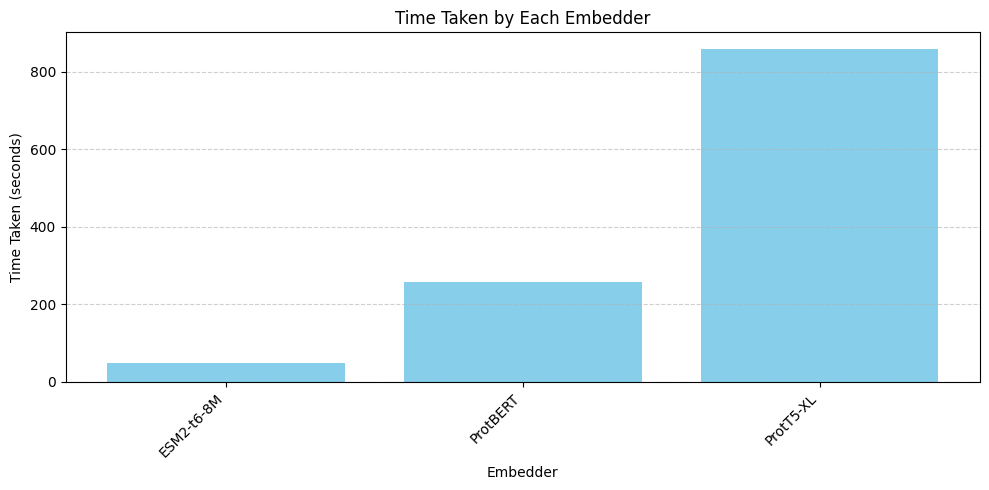

In [ ]:
# Step 3: Visualising the results

for model_name, info in results.items():
    print(f"\nModel: {model_name}")
    print(f"Embedding shape: {info['embeddings'].shape}")
    print(f"Time taken: {info['time_taken']:.2f} seconds")

# Gather data
embedder_names = list(results.keys())
time_taken = [results[model]['time_taken'] for model in embedder_names]

# Plot
plt.figure(figsize=(10, 5))
plt.bar(embedder_names, time_taken, color='skyblue')
plt.ylabel("Time Taken (seconds)")
plt.xlabel("Embedder")
plt.title("Time Taken by Each Embedder")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


--- Evaluating embedder: ESM2-t6-8M ---
Epoch [1/20], Loss: 1.1038
Epoch [5/20], Loss: 1.0094
Epoch [10/20], Loss: 0.9018
Epoch [15/20], Loss: 0.7806
Epoch [20/20], Loss: 0.6605
Accuracy: 0.4444
Weighted Precision: 0.4000
Weighted Recall: 0.4444
Weighted F1-score: 0.4198
              precision    recall  f1-score   support

     Nucleus       0.40      0.50      0.44         4
   Cytoplasm       0.00      0.00      0.00         3
    Secreted       1.00      1.00      1.00         2

    accuracy                           0.44         9
   macro avg       0.47      0.50      0.48         9
weighted avg       0.40      0.44      0.42         9

Weighted ROC AUC: 0.6556


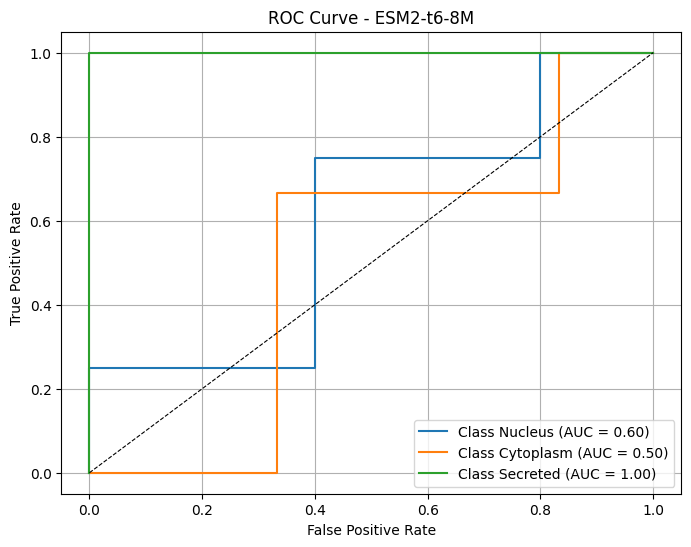


--- Evaluating embedder: ProtBERT ---
Epoch [1/20], Loss: 1.0986
Epoch [5/20], Loss: 1.0204
Epoch [10/20], Loss: 0.9231
Epoch [15/20], Loss: 0.8185
Epoch [20/20], Loss: 0.7102
Accuracy: 0.5556
Weighted Precision: 0.3704
Weighted Recall: 0.5556
Weighted F1-score: 0.4444
              precision    recall  f1-score   support

     Nucleus       0.50      0.75      0.60         4
   Cytoplasm       0.00      0.00      0.00         3
    Secreted       0.67      1.00      0.80         2

    accuracy                           0.56         9
   macro avg       0.39      0.58      0.47         9
weighted avg       0.37      0.56      0.44         9

Weighted ROC AUC: 0.7741


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


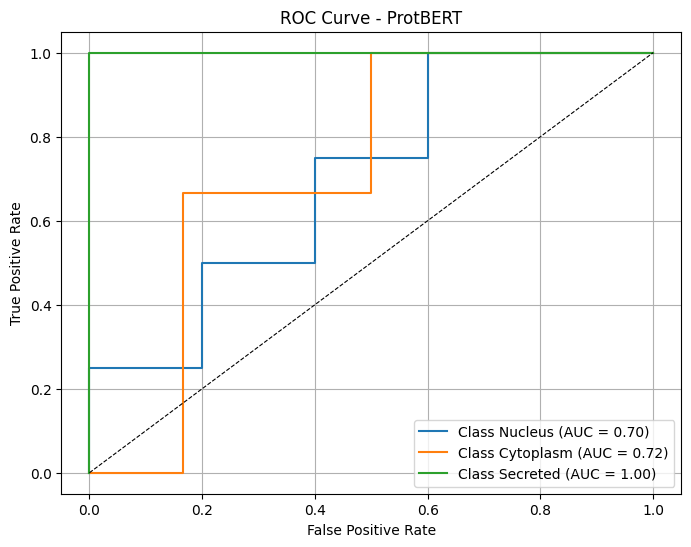


--- Evaluating embedder: ProtT5-XL ---
Epoch [1/20], Loss: 1.0980
Epoch [5/20], Loss: 0.9931
Epoch [10/20], Loss: 0.8302
Epoch [15/20], Loss: 0.6519
Epoch [20/20], Loss: 0.5111
Accuracy: 0.7778
Weighted Precision: 0.8148
Weighted Recall: 0.7778
Weighted F1-score: 0.7778
              precision    recall  f1-score   support

     Nucleus       0.75      0.75      0.75         4
   Cytoplasm       1.00      0.67      0.80         3
    Secreted       0.67      1.00      0.80         2

    accuracy                           0.78         9
   macro avg       0.81      0.81      0.78         9
weighted avg       0.81      0.78      0.78         9

Weighted ROC AUC: 0.8963


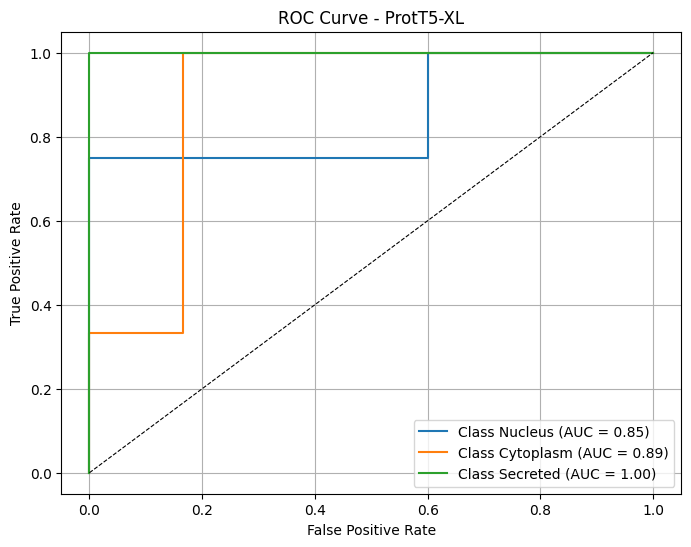

In [ ]:
# Step 4: Training a simple neural network on the data

# Defining the neural network
class ProteinClassifier(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(ProteinClassifier, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, output_dim)
        )

    def forward(self, x):
        return self.net(x)

# Training the model
for model_name, model_data in results.items():
    print(f"\n--- Evaluating embedder: {model_name} ---")

    # Get embeddings and labels
    X = model_data['embeddings']
    y = sample_df[labels].values.argmax(axis=1)
    class_names = sample_df[labels].columns.tolist()
    num_classes = len(class_names)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Compute class weights
    class_sample_count = np.array([np.sum(y_train == t) for t in np.unique(y_train)])
    class_weights = 1. / class_sample_count
    weights = class_weights[y_train]
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

    # Convert to tensors
    X_train = torch.tensor(X_train, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.long)
    X_test = torch.tensor(X_test, dtype=torch.float32)
    y_test = torch.tensor(y_test, dtype=torch.long)

    # Model
    input_dim = X_train.shape[1]
    output_dim = num_classes
    model = ProteinClassifier(input_dim, output_dim)

    # Weighted loss function
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Training loop
    num_epochs = 20
    for epoch in range(num_epochs):
        model.train()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

    # Evaluation
    model.eval()
    with torch.no_grad():
        outputs = model(X_test)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(probs, 1)

        # Metrics
        accuracy = accuracy_score(y_test, predicted)
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_test, predicted, average='weighted', zero_division=0
        )

        print(f"Accuracy: {accuracy:.4f}")
        print(f"Weighted Precision: {precision:.4f}")
        print(f"Weighted Recall: {recall:.4f}")
        print(f"Weighted F1-score: {f1:.4f}")
        print(classification_report(y_test, predicted, target_names=class_names))

        # ROC Curve & AUC
        y_test_bin = label_binarize(y_test, classes=np.arange(num_classes))
        auc_score = roc_auc_score(y_test_bin, probs.numpy(), average='weighted', multi_class='ovr')
        print(f"Weighted ROC AUC: {auc_score:.4f}")

        # Plot ROC curve
        plt.figure(figsize=(8, 6))
        for i in range(num_classes):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
            plt.plot(fpr, tpr, label=f'Class {class_names[i]} (AUC = {roc_auc_score(y_test_bin[:, i], probs[:, i]):.2f})')
        plt.plot([0, 1], [0, 1], 'k--', lw=0.8)
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve - {model_name}')
        plt.legend()
        plt.grid(True)
        plt.show()
